In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/2019-Nov.csv
/kaggle/input/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/2019-Oct.csv


# E-Commerce Behavior Dataset Sample

## 1. Project Setup

The original dataset is very large, so we only load the first 500,000 rows for analysis.

This sample is enough for building a portfolio-level user behavior and growth analysis project.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
df = pd.read_csv(
    '/kaggle/input/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/2019-Nov.csv',
    nrows=500000
)

In [4]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:00 UTC,view,1003461,2053013555631882655,electronics.smartphone,xiaomi,489.07,520088904,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33
1,2019-11-01 00:00:00 UTC,view,5000088,2053013566100866035,appliances.sewing_machine,janome,293.65,530496790,8e5f4f83-366c-4f70-860e-ca7417414283
2,2019-11-01 00:00:01 UTC,view,17302664,2053013553853497655,NaN,creed,28.31,561587266,755422e7-9040-477b-9bd2-6a6e8fd97387
3,2019-11-01 00:00:01 UTC,view,3601530,2053013563810775923,appliances.kitchen.washer,lg,712.87,518085591,3bfb58cd-7892-48cc-8020-2f17e6de6e7f
4,2019-11-01 00:00:01 UTC,view,1004775,2053013555631882655,electronics.smartphone,xiaomi,183.27,558856683,313628f1-68b8-460d-84f6-cec7a8796ef2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     500000 non-null  object 
 1   event_type     500000 non-null  object 
 2   product_id     500000 non-null  int64  
 3   category_id    500000 non-null  int64  
 4   category_code  337628 non-null  object 
 5   brand          425209 non-null  object 
 6   price          500000 non-null  float64
 7   user_id        500000 non-null  int64  
 8   user_session   500000 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 34.3+ MB


In [6]:
df.to_csv('ecommerce_behavior_sample_500k.csv', index=False)

## 2. Data Understanding

Next, we check the basic structure of the dataset, including columns, data types, missing values, and event types.

In [7]:
df.columns

Index(['event_time', 'event_type', 'product_id', 'category_id',
       'category_code', 'brand', 'price', 'user_id', 'user_session'],
      dtype='object')

In [8]:
df.isnull().sum()

event_time            0
event_type            0
product_id            0
category_id           0
category_code    162372
brand             74791
price                 0
user_id               0
user_session          0
dtype: int64

In [9]:
df['event_type'].value_counts()

event_type
view        482642
purchase      9595
cart          7763
Name: count, dtype: int64

In [10]:
df['category_code'].nunique()

123

## Initial Observation

The dataset contains user behavior logs from an e-commerce platform.

Each row represents one user action, such as viewing a product, adding it to cart, or purchasing.

The key event types include:

- view
- cart
- purchase

This dataset is suitable for funnel analysis, conversion analysis, GMV analysis, and user growth analysis.

# 3. Funnel Analysis

In this section, we analyze the user behavior funnel.

The funnel includes:

- Product View
- Add to Cart
- Purchase

The goal is to understand where users drop off during the shopping journey.

In [11]:
event_counts = df['event_type'].value_counts()

event_counts

event_type
view        482642
purchase      9595
cart          7763
Name: count, dtype: int64

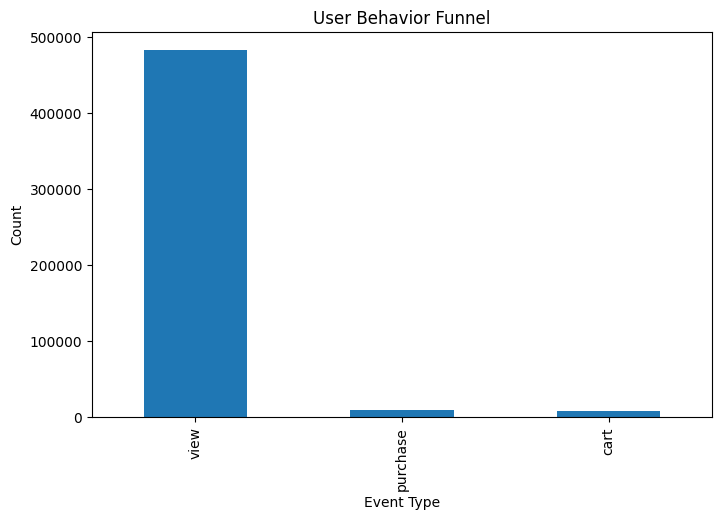

In [12]:
plt.figure(figsize=(8,5))

event_counts.plot(kind='bar')

plt.title('User Behavior Funnel')
plt.xlabel('Event Type')
plt.ylabel('Count')

plt.show()

## Funnel Observation

Most user actions are product views, while only a small portion of users proceed to cart and purchase actions.

This indicates a significant drop-off during the conversion process.

# 4. Conversion Rate Analysis

Next, we calculate conversion rates between different stages of the funnel.

In [13]:
views = event_counts['view']
carts = event_counts['cart']
purchases = event_counts['purchase']

print("Views:", views)
print("Carts:", carts)
print("Purchases:", purchases)

Views: 482642
Carts: 7763
Purchases: 9595


In [14]:
view_to_cart = carts / views
cart_to_purchase = purchases / carts
view_to_purchase = purchases / views

print("View to Cart Conversion Rate:", round(view_to_cart, 4))
print("Cart to Purchase Conversion Rate:", round(cart_to_purchase, 4))
print("View to Purchase Conversion Rate:", round(view_to_purchase, 4))

View to Cart Conversion Rate: 0.0161
Cart to Purchase Conversion Rate: 1.236
View to Purchase Conversion Rate: 0.0199


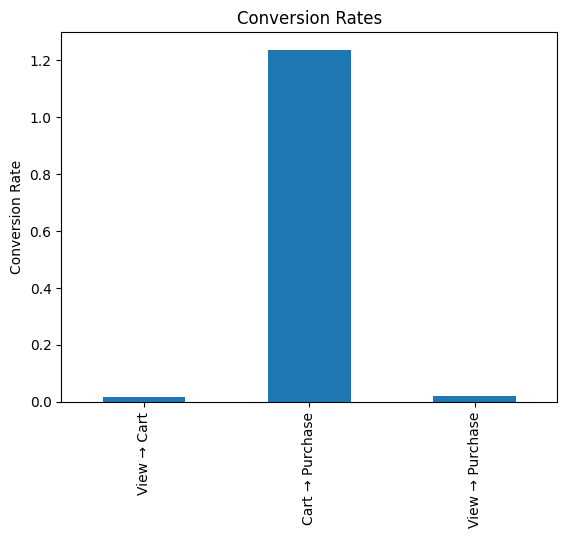

In [15]:
conversion_rates = pd.Series({
    'View → Cart': view_to_cart,
    'Cart → Purchase': cart_to_purchase,
    'View → Purchase': view_to_purchase
})

conversion_rates.plot(kind='bar')

plt.title('Conversion Rates')
plt.ylabel('Conversion Rate')

plt.show()

## Conversion Analysis Findings

The conversion rate from product view to purchase is relatively low.

This suggests that many users browse products but do not complete purchases.

Potential reasons may include:

- Weak purchase intent
- Pricing issues
- Product comparison behavior
- Checkout friction
- Insufficient product attractiveness

# 5. GMV Analysis

GMV (Gross Merchandise Value) represents the total transaction value generated on the platform.

Next, we analyze purchase revenue and pricing behavior.

In [16]:
purchase_df = df[df['event_type'] == 'purchase']

In [17]:
gmv = purchase_df['price'].sum()

print("Total GMV:", round(gmv, 2))

Total GMV: 2897621.42


In [18]:
avg_order_value = purchase_df['price'].mean()

print("Average Order Value:", round(avg_order_value, 2))

Average Order Value: 301.99


In [19]:
traffic = views
conversion_rate = view_to_purchase
aov = avg_order_value

estimated_gmv = traffic * conversion_rate * aov

print("Estimated GMV:", round(estimated_gmv, 2))

Estimated GMV: 2897621.42


## GMV Observation

GMV is influenced by three key factors:

- Traffic
- Conversion Rate
- Average Order Value (AOV)

Improving any of these components may help increase overall platform revenue.

# 6. User-Level Funnel Analysis

Event-level conversion rates may be misleading because users can directly purchase without adding items to cart.

Therefore, we conduct funnel analysis at the user level.

In [20]:
view_users = df[df['event_type'] == 'view']['user_id'].nunique()

view_users

92743

In [21]:
cart_users = df[df['event_type'] == 'cart']['user_id'].nunique()

cart_users

4501

In [22]:
purchase_users = df[df['event_type'] == 'purchase']['user_id'].nunique()

purchase_users

7389

In [23]:
view_to_cart_user = cart_users / view_users

view_to_purchase_user = purchase_users / view_users

print("User View → Cart Conversion:", round(view_to_cart_user, 4))
print("User View → Purchase Conversion:", round(view_to_purchase_user, 4))

User View → Cart Conversion: 0.0485
User View → Purchase Conversion: 0.0797


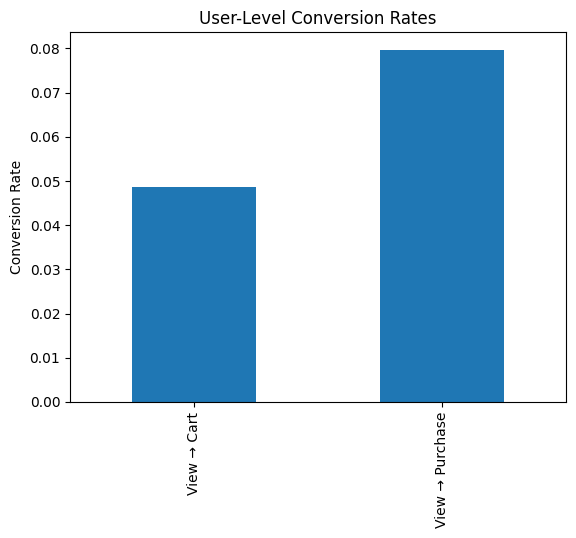

In [24]:
user_conversion = pd.Series({
    'View → Cart': view_to_cart_user,
    'View → Purchase': view_to_purchase_user
})

user_conversion.plot(kind='bar')

plt.title('User-Level Conversion Rates')
plt.ylabel('Conversion Rate')

plt.show()

## User Funnel Insights

User-level conversion analysis provides a more realistic view of customer behavior.

The results show that only a small percentage of users who viewed products eventually completed purchases.

This indicates substantial drop-off during the customer journey, suggesting opportunities to optimize:

- Product recommendation systems
- Pricing strategies
- Checkout experience
- Promotional campaigns
- Product page attractiveness

# 7. Top Product Categories Analysis

In this section, we analyze the most popular product categories based on user behavior data.

Understanding category popularity helps identify customer interests and high-traffic product segments.

In [25]:
top_categories = df['category_code'].value_counts().head(10)

top_categories

category_code
electronics.smartphone              133660
electronics.clocks                   14239
electronics.audio.headphone          13965
electronics.video.tv                 13708
computers.notebook                   13503
appliances.kitchen.washer             9986
appliances.environment.vacuum         9911
apparel.shoes                         9477
appliances.kitchen.refrigerators      9445
furniture.living_room.cabinet         6770
Name: count, dtype: int64

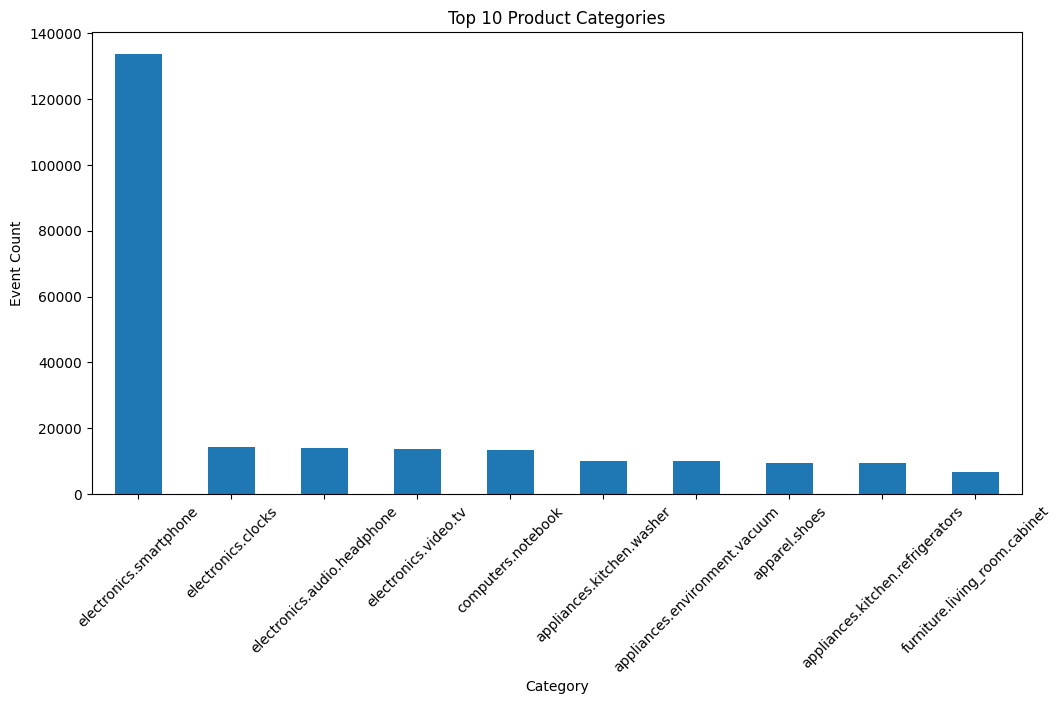

In [26]:
plt.figure(figsize=(12,6))

top_categories.plot(kind='bar')

plt.title('Top 10 Product Categories')
plt.xlabel('Category')
plt.ylabel('Event Count')

plt.xticks(rotation=45)

plt.show()

# 8. Top Brands Analysis

Next, we analyze the most active brands in the dataset.

In [27]:
top_brands = df['brand'].value_counts().head(10)

top_brands

brand
samsung     62074
apple       49605
xiaomi      36168
huawei      11758
lucente      7634
oppo         6616
cordiant     6457
lg           6189
bosch        5800
sony         5451
Name: count, dtype: int64

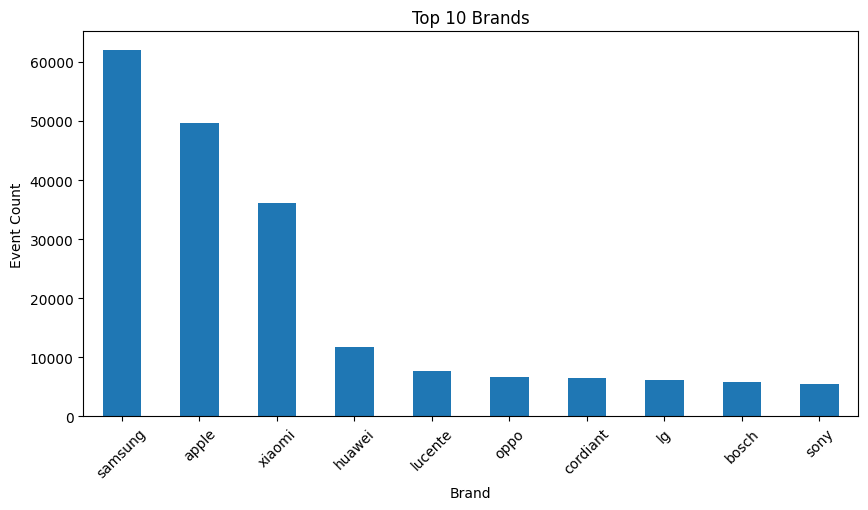

In [28]:
plt.figure(figsize=(10,5))

top_brands.plot(kind='bar')

plt.title('Top 10 Brands')
plt.xlabel('Brand')
plt.ylabel('Event Count')

plt.xticks(rotation=45)

plt.show()

# 9. Purchase Behavior Analysis

We now focus on purchase events to identify the most valuable categories and brands.

In [35]:
purchase_df = df[df['event_type'] == 'purchase']

In [36]:
top_purchase_categories = purchase_df['category_code'].value_counts().head(10)

top_purchase_categories

category_code
electronics.smartphone              4357
electronics.audio.headphone          395
electronics.video.tv                 258
electronics.clocks                   195
appliances.kitchen.washer            184
appliances.environment.vacuum        144
computers.notebook                   143
appliances.kitchen.refrigerators     132
electronics.tablet                    63
computers.desktop                     59
Name: count, dtype: int64

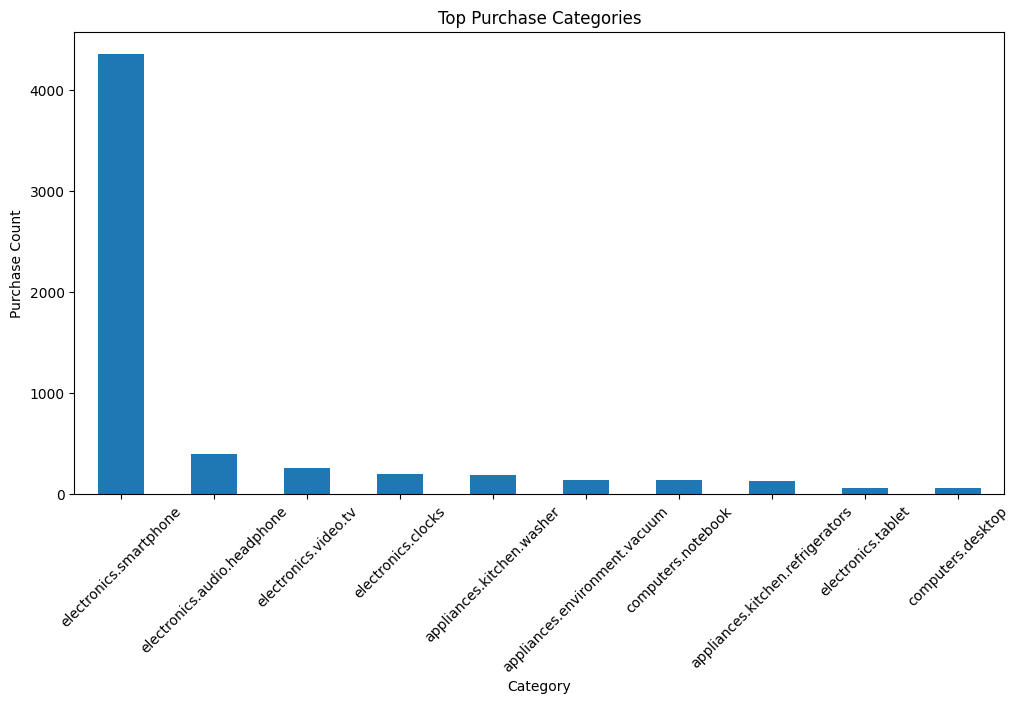

In [37]:
plt.figure(figsize=(12,6))

top_purchase_categories.plot(kind='bar')

plt.title('Top Purchase Categories')
plt.xlabel('Category')
plt.ylabel('Purchase Count')

plt.xticks(rotation=45)

plt.show()

In [38]:
top_purchase_brands = purchase_df['brand'].value_counts().head(10)

top_purchase_brands

brand
samsung     2289
apple       1766
xiaomi       680
huawei       261
cordiant     220
oppo         158
lucente      137
nokian       123
triangle     119
lg           108
Name: count, dtype: int64

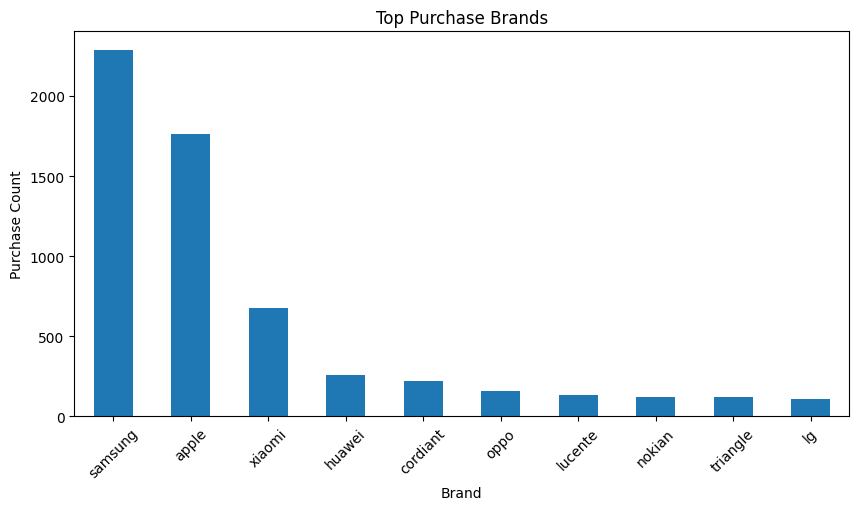

In [39]:
plt.figure(figsize=(10,5))

top_purchase_brands.plot(kind='bar')

plt.title('Top Purchase Brands')
plt.xlabel('Brand')
plt.ylabel('Purchase Count')

plt.xticks(rotation=45)

plt.show()

# Key Business Insights

The analysis shows that electronics-related categories dominate user activity and purchases.

Several brands consistently appear among the top purchase rankings, indicating strong customer demand and brand influence.

These insights may help e-commerce platforms optimize:

- Product recommendation strategies
- Inventory allocation
- Advertising investment
- Promotion planning
- Homepage exposure priorities

# 10. Daily Active Users (DAU) Analysis

In this section, we analyze daily active users (DAU) to understand platform activity trends over time.

DAU is one of the most important metrics in user growth and product analytics.

In [58]:
df['event_time'] = pd.to_datetime(df['event_time'])

In [48]:
df['date'] = df['event_time'].dt.date

In [47]:
df[['event_time', 'date']].head()

,event_time,date
0,2019-11-01 00:00:00+00:00,2019-11-01
1,2019-11-01 00:00:00+00:00,2019-11-01
2,2019-11-01 00:00:01+00:00,2019-11-01
3,2019-11-01 00:00:01+00:00,2019-11-01
4,2019-11-01 00:00:01+00:00,2019-11-01


In [60]:
dau = df.groupby('date')['user_id'].nunique()

In [61]:
dau.head()

date
2019-11-01    92750
Name: user_id, dtype: int64

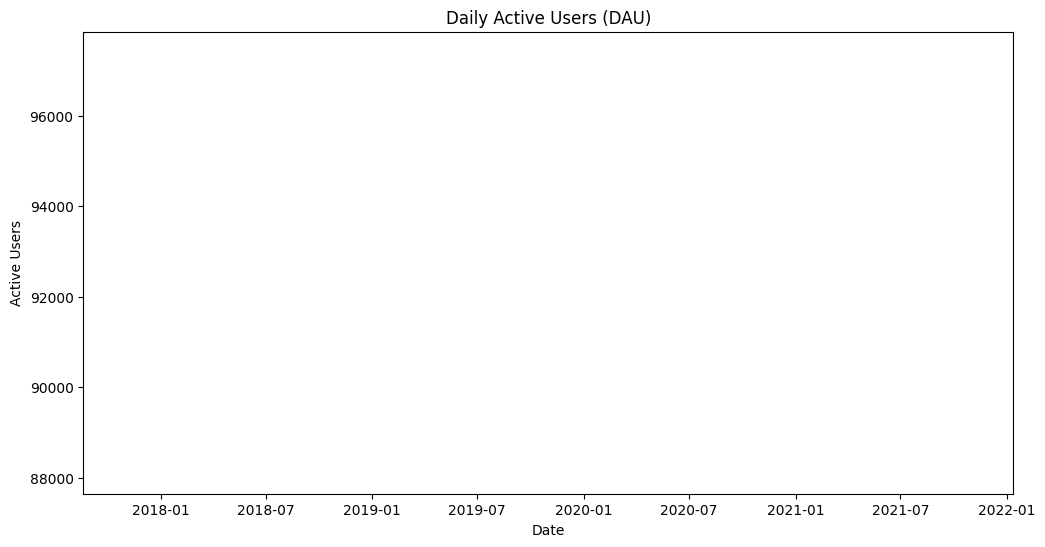

In [62]:
plt.figure(figsize=(12,6))

dau.plot()

plt.title('Daily Active Users (DAU)')
plt.xlabel('Date')
plt.ylabel('Active Users')

plt.show()

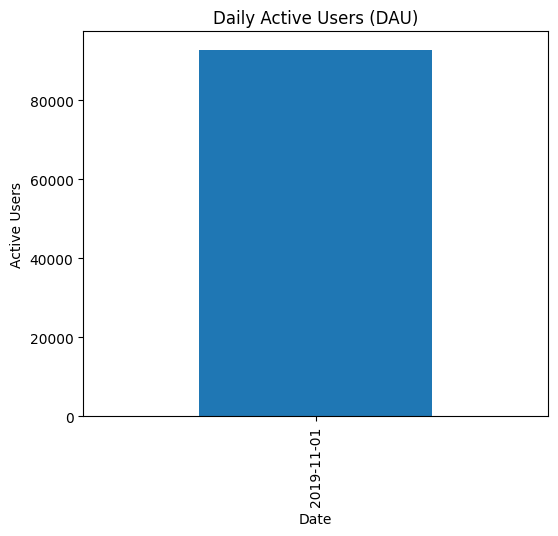

In [63]:
plt.figure(figsize=(6,5))

dau.plot(kind='bar')

plt.title('Daily Active Users (DAU)')
plt.xlabel('Date')
plt.ylabel('Active Users')

plt.show()

# DAU Insights

DAU reflects overall platform activity and user engagement trends.

By monitoring DAU changes over time, companies can identify:

- Growth opportunities
- User engagement patterns
- Seasonal trends
- Marketing campaign impacts
- Potential platform issues

# 11. High-Value User Analysis

In this section, we identify high-value users based on purchase behavior and spending amount.

Understanding high-value users is important for customer retention and personalized marketing strategies.

In [64]:
purchase_df = df[df['event_type'] == 'purchase']

In [65]:
user_spending = purchase_df.groupby('user_id')['price'].sum()

In [66]:
top_users = user_spending.sort_values(ascending=False).head(10)

top_users

user_id
515934670    16222.80
566145046    11118.74
515715331    10463.22
551058738     7786.25
525009852     6749.55
566370779     6715.24
513932302     6706.33
512395471     6449.40
514791549     6398.07
556981496     6027.96
Name: price, dtype: float64

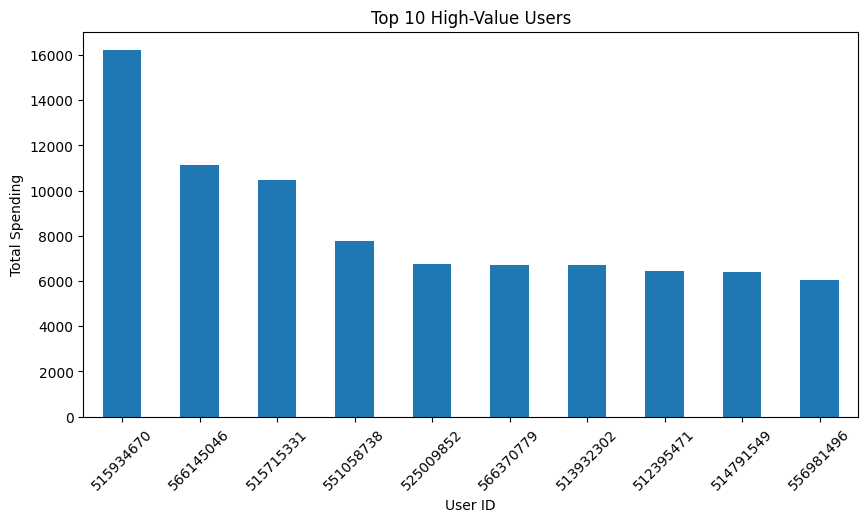

In [67]:
plt.figure(figsize=(10,5))

top_users.plot(kind='bar')

plt.title('Top 10 High-Value Users')
plt.xlabel('User ID')
plt.ylabel('Total Spending')

plt.xticks(rotation=45)

plt.show()

# 12. User Spending Distribution

Next, we analyze the distribution of user spending behavior.

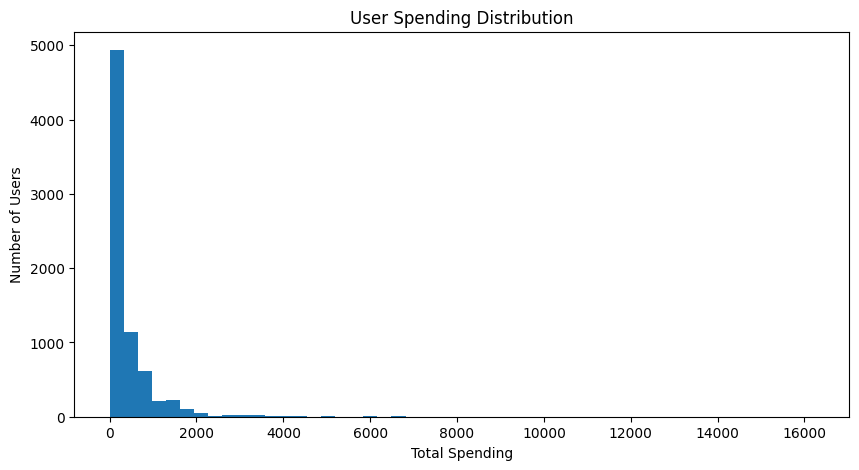

In [68]:
plt.figure(figsize=(10,5))

plt.hist(user_spending, bins=50)

plt.title('User Spending Distribution')
plt.xlabel('Total Spending')
plt.ylabel('Number of Users')

plt.show()

# High-Value User Insights

The spending distribution shows a strong long-tail pattern.

A relatively small number of users contribute a disproportionately large share of total revenue.

This suggests that high-value users are critical for platform profitability.

Potential business strategies include:

- VIP membership programs
- Personalized recommendations
- Loyalty rewards
- Retention campaigns for high-value users

# 13. User Segmentation Analysis

In this section, users are segmented based on their spending behavior.

User segmentation helps companies design targeted marketing and retention strategies for different customer groups.

In [69]:
user_spending.describe()

count     7389.000000
mean       392.153393
std        612.562163
min          1.000000
25%         83.660000
50%        193.020000
75%        458.280000
max      16222.800000
Name: price, dtype: float64

## Segmentation Strategy

Users are divided into three groups:

- Low-value users
- Medium-value users
- High-value users

In [70]:
q1 = user_spending.quantile(0.33)
q2 = user_spending.quantile(0.66)

print("33% Quantile:", q1)
print("66% Quantile:", q2)

33% Quantile: 125.61
66% Quantile: 313.87919999999986


In [72]:
def segment_user(x):

    if x <= q1:
        return 'Low Value'

    elif x <= q2:
        return 'Medium Value'

    else:
        return 'High Value'

In [74]:
user_segments = user_spending.apply(segment_user)

In [75]:
user_segments.value_counts()

price
High Value      2512
Low Value       2448
Medium Value    2429
Name: count, dtype: int64

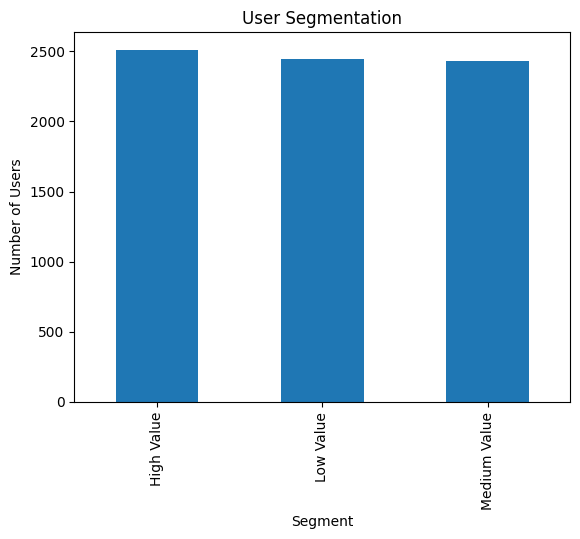

In [76]:
user_segments.value_counts().plot(kind='bar')

plt.title('User Segmentation')
plt.xlabel('Segment')
plt.ylabel('Number of Users')

plt.show()

# User Segmentation Insights

The platform contains users with significantly different spending behaviors.

Most users belong to the low-value segment, while a smaller group of high-value users contributes a large portion of platform revenue.

This suggests that personalized strategies may improve overall business performance.

Potential strategies include:

- VIP programs for high-value users
- Personalized promotions
- Retention campaigns
- Loyalty rewards
- Targeted recommendations

# 14. RFM Analysis

RFM analysis is a customer segmentation method based on:

- Recency
- Frequency
- Monetary

It is widely used in e-commerce and CRM analytics to understand customer value and engagement.

In [81]:
purchase_df = df[df['event_type'] == 'purchase'].copy()

In [87]:
purchase_df['event_time'] = pd.to_datetime(purchase_df['event_time'])

In [88]:
snapshot_date = purchase_df['event_time'].max()

snapshot_date

Timestamp('2019-11-01 09:18:16+0000', tz='UTC')

In [89]:
rfm = purchase_df.groupby('user_id').agg({

    'event_time': lambda x: (snapshot_date - x.max()).days,

    'user_session': 'count',

    'price': 'sum'

})

In [91]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [92]:
rfm.head()

,Recency,Frequency,Monetary
user_id,,,
356520186,0,1,33.45
397023870,0,1,244.28
486999716,0,1,242.72
509881222,0,1,200.52
512364896,0,5,708.01


In [93]:
rfm.describe()

,Recency,Frequency,Monetary
count,7389.0,7389.000000,7389.000000
mean,0.0,1.298552,392.153393
std,0.0,0.921190,612.562163
min,0.0,1.000000,1.000000
25%,0.0,1.000000,83.660000
50%,0.0,1.000000,193.020000
75%,0.0,1.000000,458.280000
max,0.0,17.000000,16222.800000


# RFM Distribution Analysis

Next, we visualize the distribution of Recency, Frequency, and Monetary metrics.

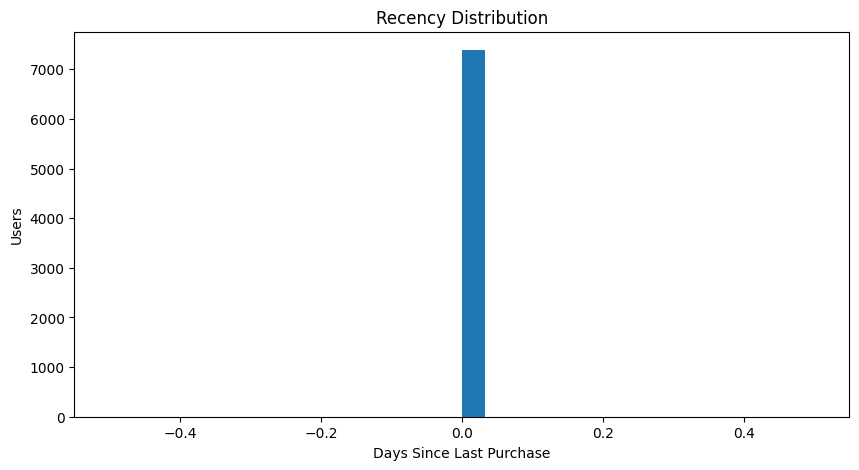

In [94]:
plt.figure(figsize=(10,5))

plt.hist(rfm['Recency'], bins=30)

plt.title('Recency Distribution')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Users')

plt.show()

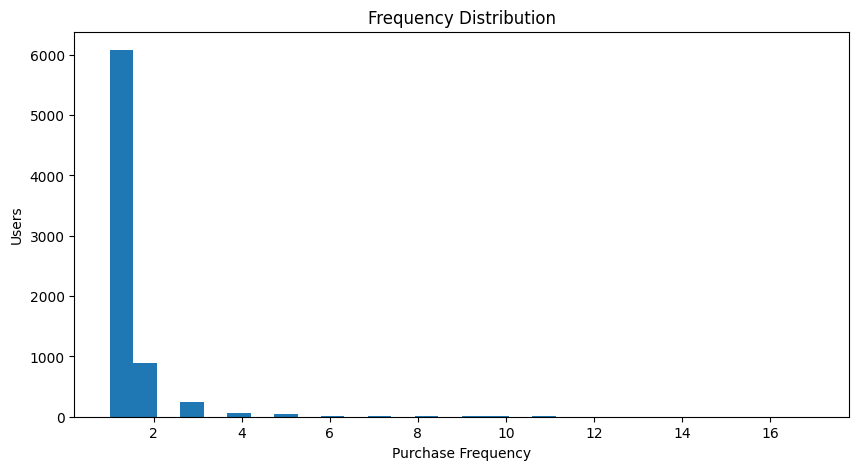

In [95]:
plt.figure(figsize=(10,5))

plt.hist(rfm['Frequency'], bins=30)

plt.title('Frequency Distribution')
plt.xlabel('Purchase Frequency')
plt.ylabel('Users')

plt.show()

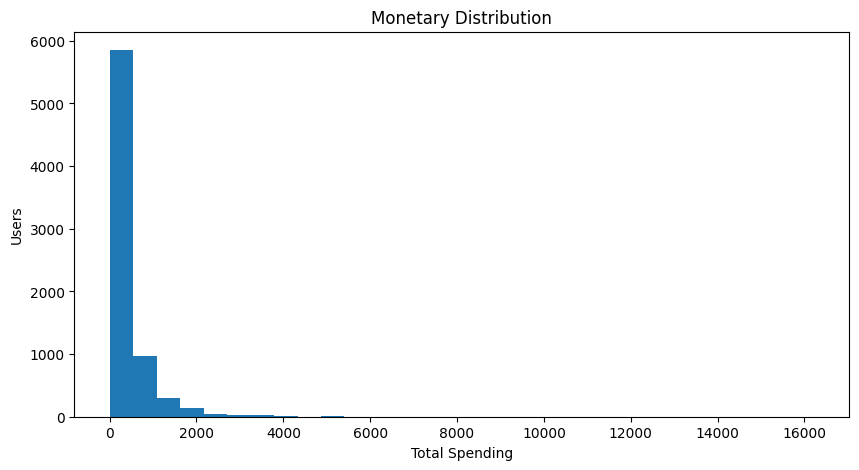

In [96]:
plt.figure(figsize=(10,5))

plt.hist(rfm['Monetary'], bins=30)

plt.title('Monetary Distribution')
plt.xlabel('Total Spending')
plt.ylabel('Users')

plt.show()

# RFM Insights

The RFM analysis reveals substantial differences in customer purchasing behavior.

Some users purchase frequently and spend significantly more than others, indicating the existence of high-value customer groups.

Potential business applications include:

- VIP customer targeting
- Personalized recommendation systems
- Retention campaigns
- Reactivation strategies for inactive users
- Loyalty program optimization

# Data Limitation

The Recency metric shows limited variation because the analysis only uses a sampled subset of the dataset covering a short time window.

As a result, most purchase events occurred on the same day, causing Recency values to remain close to zero.

Despite this limitation, Frequency and Monetary metrics still provide meaningful insights into customer purchasing behavior.

# 15. Correlation Analysis

Next, we analyze the relationship between purchase frequency and total spending.

Understanding this relationship helps evaluate whether frequent customers contribute more revenue.

In [97]:
correlation = rfm[['Frequency', 'Monetary']].corr()

correlation

,Frequency,Monetary
Frequency,1.000000,0.503912
Monetary,0.503912,1.000000


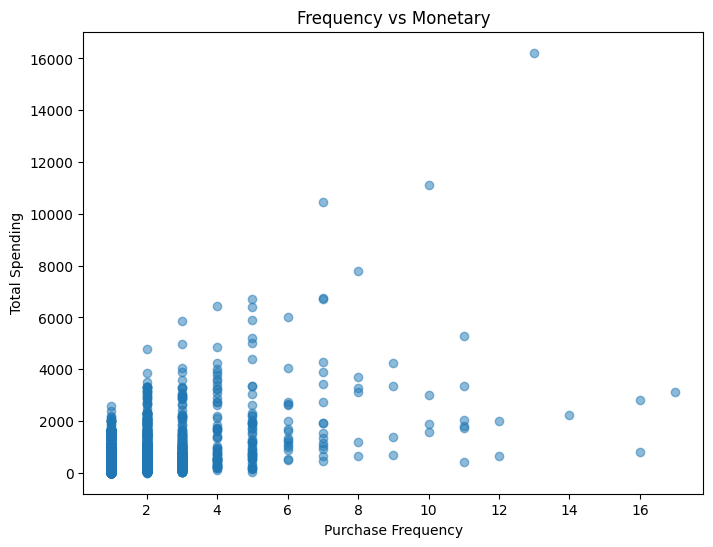

In [98]:
plt.figure(figsize=(8,6))

plt.scatter(
    rfm['Frequency'],
    rfm['Monetary'],
    alpha=0.5
)

plt.title('Frequency vs Monetary')
plt.xlabel('Purchase Frequency')
plt.ylabel('Total Spending')

plt.show()

# Correlation Insights

The analysis suggests a positive relationship between purchase frequency and total spending.

Users who purchase more frequently tend to contribute higher overall revenue.

This highlights the importance of increasing customer retention and repeat purchase behavior.

Potential business strategies include:

- Membership programs
- Personalized promotions
- Loyalty rewards
- Repeat-purchase incentives

# 16. Executive Summary

This project analyzed real-world e-commerce user behavior data to understand customer engagement, conversion behavior, and purchasing patterns.

The analysis included:

- Funnel analysis
- Conversion rate analysis
- GMV analysis
- Product category analysis
- Brand analysis
- User segmentation
- RFM analysis
- Correlation analysis

Key findings show that:

- Most users browse products but do not complete purchases
- A small number of high-value users contribute a large share of total revenue
- Electronics-related products dominate platform activity
- Purchase frequency is positively related to total spending
- Customer behavior follows a strong long-tail distribution

These insights may help e-commerce platforms improve:

- Customer retention
- Personalized recommendation systems
- Marketing efficiency
- Revenue growth strategies
- User segmentation and targeting

# 17. Business Value

This project demonstrates practical skills in:

- Product analytics
- User growth analysis
- Funnel analysis
- Customer segmentation
- Revenue analysis
- Data visualization
- Business insight generation

The workflow reflects real-world analytical thinking commonly used in e-commerce and internet companies.

# 18. Technical Skills Demonstrated

- Python
- Pandas
- NumPy
- Matplotlib
- Data Cleaning
- Exploratory Data Analysis (EDA)
- RFM Analysis
- User Segmentation
- Correlation Analysis
- Business Analytics